Évaluation du modèle 'agent_par_defaut' avec 5834 exemples.


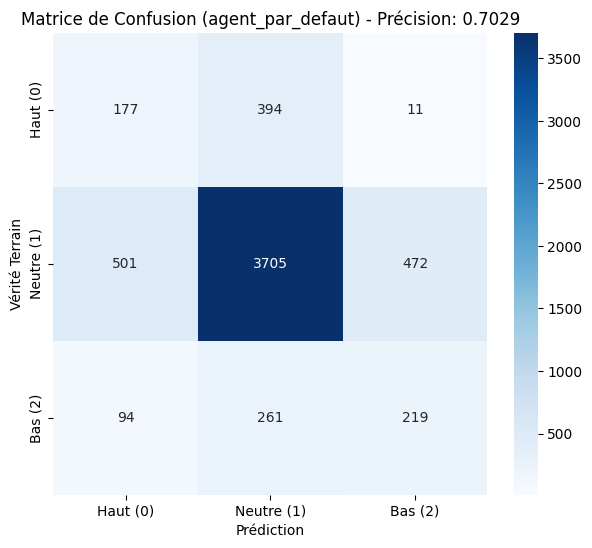

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# --- Configuration ---
AGENT_JSON = "AgentsIA/agent_5_-_5_entrees_sans_filtre.json"
DATASET_CSV = "DatasetsAUtiliser\pong_data_test_1.csv" # Mettez le chemin d'un CSV d'entraînement/test ici

# La logique de prédiction Python doit imiter votre DLL C++
def predict_multiclass_perceptron(X, weights, biases):
    """Calcule la prédiction (produit scalaire, pas de fonction d'activation de sortie)
    et sélectionne la classe avec la plus grande valeur."""
    
    # X : (rows, 5), weights : (3, 5), biases : (3,)
    # Le calcul est (X @ weights.T) + biases
    
    # 1. Produit matriciel (produit scalaire par classe)
    # weights est (3, 5), X est (N, 5). Transposer les poids ou utiliser dot/matmul correctement.
    # Dans notre cas, nous avons Poids[classe][entrée]
    dot_product = X @ weights.T # Résultat: (N, 3) - score pour chaque classe
    
    # 2. Ajout des biais
    scores = dot_product + biases
    
    # 3. La prédiction est l'indice de la classe avec le score max
    predictions = np.argmax(scores, axis=1)
    
    return predictions

def charger_dataset(chemin_fichier):
    """Charge et prépare les données d'entrée (X) et de sortie (Y) comme dans votre C++ (Version 4)."""
    # Votre C++ utilise les colonnes : ballX, ballY, ballVX, ballVY, playerY (indices 0, 1, 2, 3, 4)
    # et la cible (Y) est la colonne playerMove (indice 6) mappée à 0, 1, 2.
    try:
        df = pd.read_csv(chemin_fichier, header=None)
        
        # Filtre et colonnes basées sur la V4 de votre C++:
        # X: indices 0 à 4
        X_data = df.iloc[:, [0, 1, 2, 3, 4]].values
        
        # Y: index 6 (playerMove)
        raw_output = df.iloc[:, 6].values
        
        # Mapping C++ : -1.0 (Haut) -> 0, 0.0 (Neutre) -> 1, 1.0 (Bas) -> 2
        Y_mapped = np.where(raw_output < -0.5, 0, np.where(raw_output > 0.5, 2, 1))
        
        # Note : Votre code C++ applique un filtre sur les neutres (compteurNeutres >= 1500).
        # Pour une évaluation fidèle, il faudrait réappliquer ce filtre si vous utilisez
        # le même fichier. Ici, nous chargeons toutes les données pour un aperçu complet.
        
        return X_data, Y_mapped
    except Exception as e:
        print(f"Erreur lors du chargement ou du prétraitement du dataset: {e}")
        return None, None

def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    """Affiche la Matrice de Confusion."""
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'], 
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']
    )
    plt.title(f"Matrice de Confusion ({nom_agent}) - Précision: {acc:.4f}")
    plt.xlabel("Prédiction")
    plt.ylabel("Vérité Terrain")
    plt.show() # 


def evaluer_modele():
    """Fonction principale pour charger l'agent et évaluer les performances."""
    try:
        with open(AGENT_JSON, 'r') as f:
            agent_info = json.load(f)
    except FileNotFoundError:
        print(f"Erreur: Le fichier agent.json n'a pas été trouvé à '{AGENT_JSON}'.")
        return
    except json.JSONDecodeError:
        print("Erreur: Le fichier agent.json est mal formé.")
        return

    nom_agent = agent_info.get("nom", "Agent_MLP")
    poids = np.array(agent_info.get("poids", [])) # (3, 5)
    biais = np.array(agent_info.get("biais", [])) # (3,)

    if poids.size == 0 or biais.size == 0:
        print("Les poids ou les biais n'ont pas été chargés correctement depuis le JSON.")
        return

    # Charger les données (X: entrée, Y: vérité terrain)
    X, Y_true = charger_dataset(DATASET_CSV)
    if X is None:
        return

    print(f"Évaluation du modèle '{nom_agent}' avec {X.shape[0]} exemples.")
    
    # 1. Faire la prédiction
    Y_pred = predict_multiclass_perceptron(X, poids, biais)
    
    # 2. Afficher les résultats
    visualiser_matrice_confusion(Y_true, Y_pred, nom_agent)

evaluer_modele()

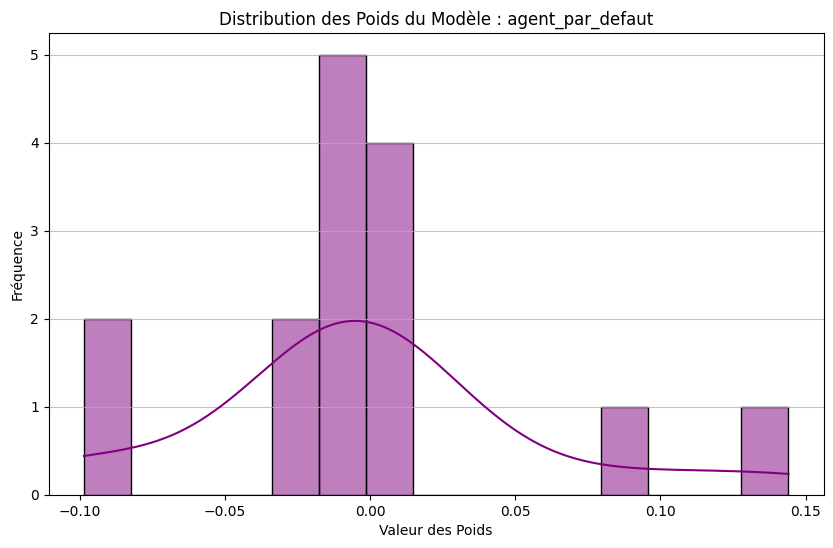

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

AGENT_JSON = "AgentsIA/agent_5_-_5_entrees_sans_filtre.json"

def visualiser_poids():
    """Charge les poids de l'agent JSON et les affiche dans un histogramme."""
    try:
        with open(AGENT_JSON, 'r') as f:
            agent_info = json.load(f)
    except FileNotFoundError:
        print(f"Erreur: Le fichier agent.json n'a pas été trouvé à '{AGENT_JSON}'.")
        return

    poids = np.array(agent_info.get("poids", []))
    nom_agent = agent_info.get("nom", "Agent_MLP")

    if poids.size == 0:
        print("Aucun poids trouvé dans le fichier JSON. Veuillez entraîner le modèle d'abord.")
        return

    # Aplatir le tableau 2D (3 classes x 5 entrées = 15 poids)
    poids_plat = poids.flatten()

    # Créer la visualisation
    plt.figure(figsize=(10, 6))
    sns.histplot(poids_plat, bins=15, kde=True, color='purple', edgecolor='black')
    
    plt.title(f"Distribution des Poids du Modèle : {nom_agent}")
    plt.xlabel("Valeur des Poids")
    plt.ylabel("Fréquence")
    plt.grid(axis='y', alpha=0.75)
    plt.show() # 

visualiser_poids()

Fichier de test utilisé : C:\Users\Delta\Desktop\pong_data_session_test_20251214_022528.csv
Évaluation du modèle 'agent_par_defaut' avec 3136 exemples.


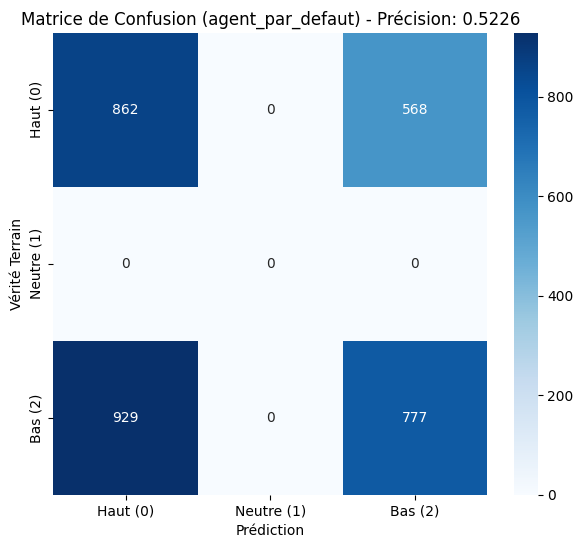

In [16]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os
import glob 

# --- Configuration ---
AGENT_JSON = "AgentsIA/agent_3_-_5_entrees_avec_equilibrage.json" 

# 1. Chemin du Bureau
desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')

# 2. Chercher le fichier de session de test le plus récent
search_pattern = os.path.join(desktop_path, "pong_data_session_test_*.csv")
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    print(f"Erreur : Aucun fichier de session de test trouvé sous '{search_pattern}'")
    exit()

# Sélectionner le fichier le plus récent (le dernier créé)
DATASET_CSV = max(list_of_files, key=os.path.getctime)
print(f"Fichier de test utilisé : {DATASET_CSV}")


# --- FONCTIONS DE PRÉDICTION ET DE CHARGEMENT ---

def predict_multiclass_perceptron(X, weights, biases):
    # Logique de prédiction du Perceptron (X @ weights.T + biases)
    dot_product = X @ weights.T
    scores = dot_product + biases
    predictions = np.argmax(scores, axis=1)
    return predictions

def charger_dataset(chemin_fichier):
    # Charge et prépare les 5 entrées (indices 0 à 4) et la cible mappée (indice 6)
    try:
        df = pd.read_csv(chemin_fichier, header=None)
        
        # X: indices 0 à 4 (ballX, ballY, ballVX, ballVY, playerY)
        X_data = df.iloc[:, [0, 1, 2, 3, 4]].values
        
        # Y: index 6 (playerMove)
        raw_output = df.iloc[:, 6].values
        
        # MAPPING CORRIGÉ: 1.0 (Haut) -> 0; -1.0 (Bas) -> 2; 0.0 (Neutre) -> 1
        Y_mapped = np.where(raw_output < -0.5, 2, np.where(raw_output > 0.5, 0, 1))
        
        return X_data, Y_mapped
    except Exception as e:
        print(f"Erreur lors du chargement ou du prétraitement du dataset: {e}")
        return None, None

def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    """Affiche la Matrice de Confusion."""
    
    # Forcer les labels [0, 1, 2] pour garantir une matrice 3x3
    labels = [0, 1, 2]
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'], 
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']
    )
    plt.title(f"Matrice de Confusion ({nom_agent}) - Précision: {acc:.4f}")
    plt.xlabel("Prédiction")
    plt.ylabel("Vérité Terrain")
    plt.show() 


# --- FONCTION PRINCIPALE ---
def evaluer_modele():
    """Fonction principale pour charger l'agent et évaluer les performances."""
    try:
        with open(AGENT_JSON, 'r') as f:
            agent_info = json.load(f)
    except FileNotFoundError:
        print(f"Erreur: Le fichier agent.json n'a pas été trouvé à '{AGENT_JSON}'.")
        return
    except json.JSONDecodeError:
        print("Erreur: Le fichier agent.json est mal formé.")
        return

    nom_agent = agent_info.get("nom", "Agent_MLP")
    poids = np.array(agent_info.get("poids", [])) 
    biais = np.array(agent_info.get("biais", [])) 

    if poids.size == 0 or biais.size == 0:
        print("Les poids ou les biais n'ont pas été chargés correctement depuis le JSON.")
        return

    # Charger les données (X: entrée, Y: vérité terrain) depuis le fichier de test récent
    X, Y_true = charger_dataset(DATASET_CSV)
    if X is None:
        return

    print(f"Évaluation du modèle '{nom_agent}' avec {X.shape[0]} exemples.")
    
    # 1. Faire la prédiction
    Y_pred = predict_multiclass_perceptron(X, poids, biais)
    
    # 2. Afficher les résultats
    visualiser_matrice_confusion(Y_true, Y_pred, nom_agent)

# --- Exécution ---
evaluer_modele()

Fichier de test utilisé : C:\Users\Delta\Desktop\pong_data_session_test_20251214_195704.csv
Évaluation du modèle 'agent_5_equilibrage_6000_epochs' avec 3124 exemples.


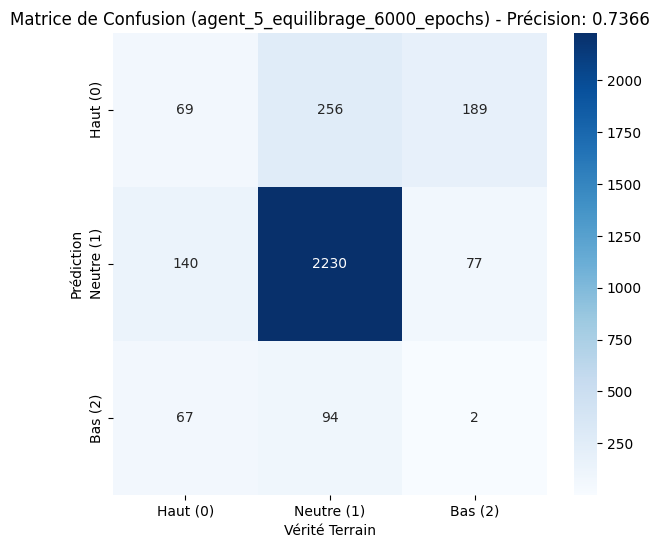

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os
import glob 

# --- 1. DONNÉES DE L'AGENT 5 (Intégrées) ---
AGENT_NOM = "agent_5_equilibrage_6000_epochs"
POIDS = np.array([
    [-0.00879281, -0.0985341, -0.0182338, -0.0190199, 0.144118],
    [0.010568, -0.0120714, 0.00817347, -0.00812635, -0.00747582],
    [-0.0107871, 0.0876027, 0.00052795, 0.014273, -0.0976165]
])
BIAIS = np.array([-0.0307193, -0.00298402, -0.0212115])


# --- 2. DÉTERMINER LE FICHIER DE TEST (Cherche le plus récent sur le Bureau) ---

desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')
search_pattern = os.path.join(desktop_path, "pong_data_session_test_*.csv")
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    print(f"Erreur : Aucun fichier de session de test trouvé sous '{search_pattern}'")
    exit()

# Sélectionner le fichier de test le plus récent
DATASET_CSV = max(list_of_files, key=os.path.getctime)
print(f"Fichier de test utilisé : {DATASET_CSV}")


# --- 3. FONCTIONS CORE ---

def predict_multiclass_perceptron(X, weights, biases):
    """Calcule les scores et retourne l'indice de la classe max (0, 1 ou 2)."""
    dot_product = X @ weights.T
    scores = dot_product + biases
    predictions = np.argmax(scores, axis=1)
    return predictions

def charger_dataset(chemin_fichier):
    """Charge et mappe les données du CSV."""
    try:
        df = pd.read_csv(chemin_fichier, header=None)
        
        # X: indices 0 à 4 (les 5 entrées de l'agent)
        X_data = df.iloc[:, [0, 1, 2, 3, 4]].values
        
        # Y: index 6 (l'action cible du joueur)
        raw_output = df.iloc[:, 6].values
        
        # MAPPING CORRIGÉ: 1.0 (Haut) -> 0; -1.0 (Bas) -> 2; 0.0 (Neutre) -> 1
        Y_mapped = np.where(raw_output < -0.5, 2, np.where(raw_output > 0.5, 0, 1))
        
        return X_data, Y_mapped
    except Exception as e:
        print(f"Erreur lors du chargement ou du prétraitement du dataset: {e}")
        return None, None

def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    """Affiche la Matrice de Confusion avec les axes inversés (Prédiction à gauche, Vérité en haut)."""
    
    labels = [0, 1, 2]
    
    # 🚨 INVERSION DES AXES : Nous passons Y_pred en premier (ligne/axe Y) et Y_true en second (colonne/axe X)
    cm = confusion_matrix(y_pred, y_true, labels=labels)
    
    # L'accuracy se calcule toujours Vérité vs Prédiction (Y_true, Y_pred)
    acc = accuracy_score(y_true, y_pred) 
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        
        # 🚨 INVERSION DES LABELS D'AFFICHAGE : 
        # X labels (en haut) correspondent à Y_true (Vérité Terrain)
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'], 
        # Y labels (à gauche) correspondent à Y_pred (Prédiction)
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']
    )
    plt.title(f"Matrice de Confusion ({nom_agent}) - Précision: {acc:.4f}")
    
    # 🚨 INVERSION DES LIBELLÉS D'AXE :
    plt.xlabel("Vérité Terrain") 
    plt.ylabel("Prédiction") 
    plt.show() 


# --- 4. EXÉCUTION ---

def evaluer_modele():
    """Fonction principale pour charger l'agent et évaluer les performances."""
    
    # Charger les données (X: entrée, Y: vérité terrain) depuis le fichier de test récent
    X, Y_true = charger_dataset(DATASET_CSV)
    if X is None:
        return

    print(f"Évaluation du modèle '{AGENT_NOM}' avec {X.shape[0]} exemples.")
    
    # 1. Faire la prédiction
    Y_pred = predict_multiclass_perceptron(X, POIDS, BIAIS)
    
    # 2. Afficher les résultats
    visualiser_matrice_confusion(Y_true, Y_pred, AGENT_NOM)

if __name__ == "__main__":
    evaluer_modele()

ATTENTION: Erreur de traitement pour pong_data_test_2.csv. [Errno 2] No such file or directory: 'pong_data_test_2.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_3.csv. [Errno 2] No such file or directory: 'pong_data_test_3.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_4.csv. [Errno 2] No such file or directory: 'pong_data_test_4.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_5.csv. [Errno 2] No such file or directory: 'pong_data_test_5.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_6.csv. [Errno 2] No such file or directory: 'pong_data_test_6.csv'. Ignoré.


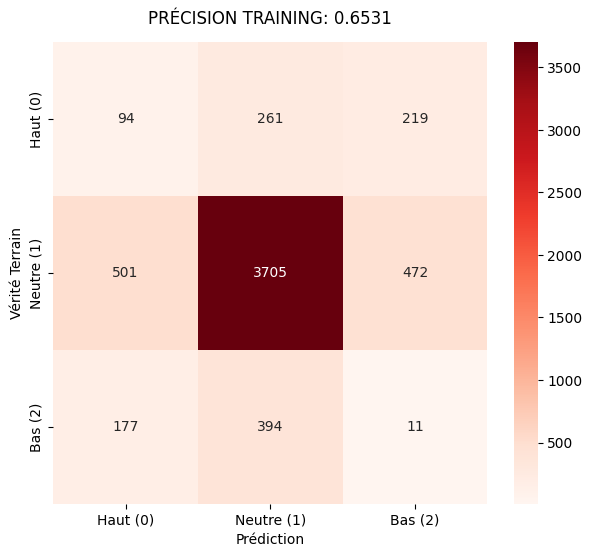

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os
import glob 

# --- 1. DONNÉES DE L'AGENT 5 (Intégrées) ---
AGENT_NOM = "agent_5_training_evaluation"
POIDS = np.array([
    [-0.00879281, -0.0985341, -0.0182338, -0.0190199, 0.144118],
    [0.010568, -0.0120714, 0.00817347, -0.00812635, -0.00747582],
    [-0.0107871, 0.0876027, 0.00052795, 0.014273, -0.0976165]
])
BIAIS = np.array([-0.0307193, -0.00298402, -0.0212115])

# Liste des 6 fichiers d'entraînement
TRAINING_FILES = [
    "pong_data_test_1.csv", "pong_data_test_2.csv", "pong_data_test_3.csv", 
    "pong_data_test_4.csv", "pong_data_test_5.csv", "pong_data_test_6.csv"
]

# --- 2. FONCTIONS CORE ---

def predict_multiclass_perceptron(X, weights, biases):
    """Calcule les scores et retourne l'indice de la classe max (0, 1 ou 2)."""
    dot_product = X @ weights.T
    scores = dot_product + biases
    predictions = np.argmax(scores, axis=1)
    return predictions

def charger_et_concatener_datasets(file_list):
    """Charge et concatène les 6 fichiers de training."""
    all_X = []
    all_Y = []
    
    for chemin_fichier in file_list:
        try:
            df = pd.read_csv(chemin_fichier, header=None)
            X_data = df.iloc[:, [0, 1, 2, 3, 4]].values
            raw_output = df.iloc[:, 6].values
            
            # MAPPING CORRIGÉ: 1.0 (Haut) -> 0; -1.0 (Bas) -> 2; 0.0 (Neutre) -> 1
            Y_mapped = np.where(raw_output < -0.5, 2, np.where(raw_output > 0.5, 0, 1))
            
            all_X.append(X_data)
            all_Y.append(Y_mapped)
            
        except Exception as e:
            print(f"ATTENTION: Erreur de traitement pour {chemin_fichier}. {e}. Ignoré.")
            
    if not all_X:
        return None, None
        
    return np.concatenate(all_X), np.concatenate(all_Y)


def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    """Affiche la Matrice de Confusion (DESIGN FINAL DEMANDÉ AVEC LABELS D'AXE)."""
    
    labels = [0, 1, 2]
    
    # Standard ML Convention: Vérité (y_true) en Y, Prédiction (y_pred) en X
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred) 
    
    plt.figure(figsize=(7, 6))
    
    # --- APPLICATION DU DESIGN FINAL ---
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Reds', # Palette Rouge
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'], 
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']
    )
    
    # Suppression du titre principal
    
    # APPLICATION DES LABELS D'AXE DEMANDÉS : Prédiction en haut, Vérité Terrain à gauche
    plt.xlabel("Prédiction") 
    plt.ylabel("Vérité Terrain")
    
    # Affichage du score de précision
    plt.text(0.5, 1.05, f"PRÉCISION TRAINING: {acc:.4f}", ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    
    plt.show() 


# --- 3. EXÉCUTION ---

def evaluer_modele_sur_training():
    """Fonction principale pour charger l'agent et évaluer les performances sur le training set."""
    
    # Chargement des données (X: entrée, Y: vérité terrain)
    X_train, Y_train_true = charger_et_concatener_datasets(TRAINING_FILES)
    if X_train is None:
        return

    # 1. Faire la prédiction sur les données de training
    Y_train_pred = predict_multiclass_perceptron(X_train, POIDS, BIAIS)
    
    # 2. Afficher les résultats
    visualiser_matrice_confusion(Y_train_true, Y_train_pred, AGENT_NOM)

if __name__ == "__main__":
    evaluer_modele_sur_training()

Fichier de test utilisé : C:\Users\Delta\Desktop\pong_data_session_test_20251214_195704.csv
Évaluation du modèle 'agent' avec 3124 exemples.


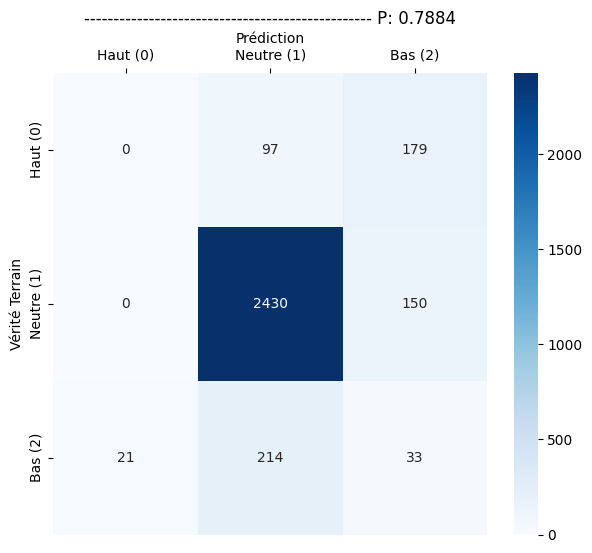

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os
import glob

# --- 1. DONNÉES DE L'AGENT ---
AGENT_NOM = "agent"
POIDS = np.array([
    [-0.00507369, -0.101397, -0.011833, -0.0100907, 0.142719],
    [0.0140353, -0.00886303, 0.0105133, -0.0017137, -0.00940377],
    [-0.0211495, 0.0877561, -0.00628415, 0.0114415, -0.0972938]
])
BIAIS = np.array([-0.0394376, 0.0038705, -0.0147509])

# --- 2. TROUVER LE FICHIER DE TEST LE PLUS RÉCENT ---
desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')
search_pattern = os.path.join(desktop_path, "pong_data_session_test_*.csv")
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    print(f"Erreur : Aucun fichier de session de test trouvé sous '{search_pattern}'")
    exit()

DATASET_CSV = max(list_of_files, key=os.path.getctime)
print(f"Fichier de test utilisé : {DATASET_CSV}")

# --- 3. FONCTIONS CORE ---

def predict_multiclass_perceptron(X, weights, biases):
    dot_product = X @ weights.T
    scores = dot_product + biases
    predictions = np.argmax(scores, axis=1)
    return predictions

def charger_dataset(chemin_fichier):
    try:
        df = pd.read_csv(chemin_fichier, header=None)
        X_data = df.iloc[:, [0,1,2,3,4]].values
        raw_output = df.iloc[:,6].values
        Y_mapped = np.where(raw_output < -0.5, 2, np.where(raw_output > 0.5, 0, 1))
        return X_data, Y_mapped
    except Exception as e:
        print(f"Erreur lors du chargement du dataset: {e}")
        return None, None

def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    labels = [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    plt.figure(figsize=(7,6))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'],   # Prédiction
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']    # Vérité terrain
    )
    # Mettre les labels X en haut
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

    plt.xlabel("Prédiction")
    plt.ylabel("Vérité Terrain")
    plt.title(f"------------------------------------------------- P: {acc:.4f}")
    plt.show()

# --- 4. EXÉCUTION ---

def evaluer_modele():
    X, Y_true = charger_dataset(DATASET_CSV)
    if X is None:
        return
    print(f"Évaluation du modèle '{AGENT_NOM}' avec {X.shape[0]} exemples.")
    
    Y_pred = predict_multiclass_perceptron(X, POIDS, BIAIS)
    visualiser_matrice_confusion(Y_true, Y_pred, AGENT_NOM)

if __name__ == "__main__":
    evaluer_modele()
